# 🔢 MNIST Handwritten Digit Recognition
**Task 2 — Machine Learning Internship**

Use the MNIST dataset to preprocess images, train a CNN model to classify handwritten digits (0–9), and evaluate its accuracy.

---
### Pipeline
1. Load & Explore the Dataset
2. Visualise Sample Images
3. Preprocess the Data
4. Build the CNN Model
5. Train the Model
6. Evaluate (Accuracy, Report)
7. Plot Training History
8. Confusion Matrix
9. Sample Predictions
10. Save the Model

## 📦 Step 0 — Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')
print(f'NumPy version     : {np.__version__}')

TensorFlow version: 2.20.0
NumPy version     : 2.2.6


##  Step 1 — Load & Explore the Dataset

MNIST is built into Keras — it contains:
- **60,000** training images
- **10,000** test images
- Each image is **28×28 pixels** in greyscale

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print('Dataset loaded successfully!')
print(f'  Training samples : {X_train.shape[0]}')
print(f'  Test samples     : {X_test.shape[0]}')
print(f'  Image shape      : {X_train.shape[1:]}  (Height x Width)')
print(f'  Pixel value range: [{X_train.min()}, {X_train.max()}]')
print(f'  Classes          : {np.unique(y_train)}  (digits 0–9)')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 16s 1us/step
Dataset loaded successfully!
  Training samples : 60000
  Test samples     : 10000
  Image shape      : (28, 28)  (Height x Width)
  Pixel value range: [0, 255]
  Classes          : [0 1 2 3 4 5 6 7 8 9]  (digits 0–9)


##  Step 2 — Visualise Sample Images

Display one sample image for each digit class (0–9).

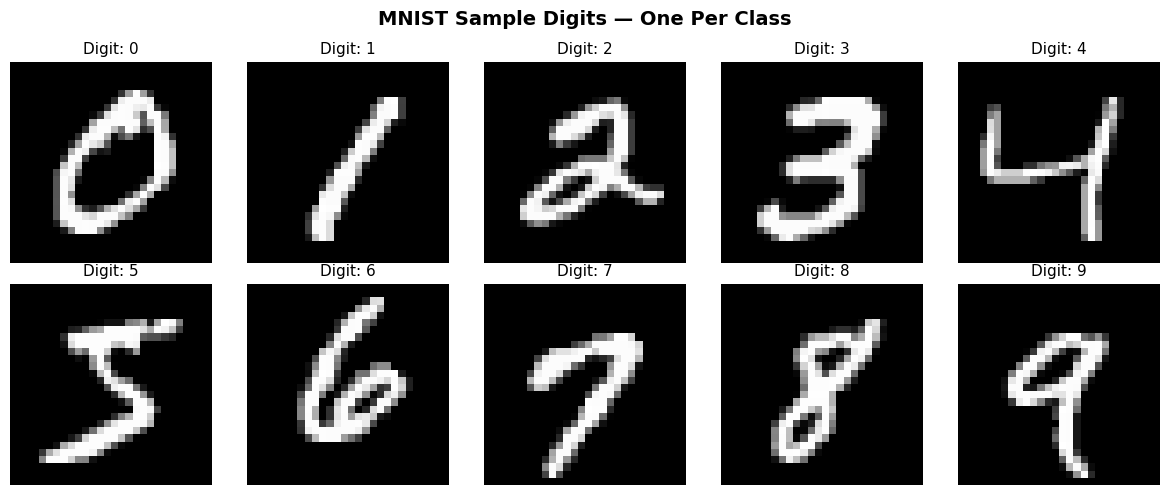

Saved → sample_digits.png


In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('MNIST Sample Digits — One Per Class', fontsize=14, fontweight='bold')

for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    ax  = axes[digit // 5][digit % 5]
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(f'Digit: {digit}', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_digits.png', dpi=120)
plt.show()
print('Saved → sample_digits.png')

##  Step 3 — Preprocess the Data

Three preprocessing steps:
1. **Reshape** — add a channel dimension: `(28, 28)` → `(28, 28, 1)` (required by CNN)
2. **Normalise** — scale pixel values from `[0, 255]` → `[0.0, 1.0]`
3. **One-hot encode** — convert labels `[0–9]` to 10-element binary vectors

In [4]:
# Keep raw labels for evaluation later
y_test_raw = y_test.copy()

# 1. Add channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

# 2. Normalise to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# 3. One-hot encode labels
y_train_ohe = tf.keras.utils.to_categorical(y_train, 10)
y_test_ohe  = tf.keras.utils.to_categorical(y_test,  10)

print('Preprocessing complete!')
print(f'  X_train shape : {X_train.shape}')
print(f'  X_test  shape : {X_test.shape}')
print(f'  Pixel range   : [{X_train.min():.1f}, {X_train.max():.1f}]')
print(f'  y_train shape (one-hot): {y_train_ohe.shape}')
print(f'  Example label : {y_train_ohe[0]}  → digit {np.argmax(y_train_ohe[0])}')

Preprocessing complete!
  X_train shape : (60000, 28, 28, 1)
  X_test  shape : (10000, 28, 28, 1)
  Pixel range   : [0.0, 1.0]
  y_train shape (one-hot): (60000, 10)
  Example label : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]  → digit 5


##  Step 4 — Build the CNN Model

Architecture:

```
Input (28×28×1)
  → Conv2D(32)  + BatchNorm + MaxPool
  → Conv2D(64)  + BatchNorm + MaxPool
  → Conv2D(128) + BatchNorm
  → Flatten → Dense(256) + Dropout(0.5)
  → Dense(10, Softmax)
```

In [5]:
model = models.Sequential([
    # ── Block 1 ─────────────────────────────────
    layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                  input_shape=(28, 28, 1), name='conv1'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # ── Block 2 ─────────────────────────────────
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # ── Block 3 ─────────────────────────────────
    layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'),
    layers.BatchNormalization(),

    # ── Classifier ──────────────────────────────
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax', name='output'),
], name='MNIST_CNN')

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

a:\Users\Hafsa\miniconda3\envs\tensorflow_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,702,026 (6.49 MB)

 Trainable params: 1,701,578 (6.49 MB)

 Non-trainable params: 448 (1.75 KB)

## Step 5 — Train the Model

- **EarlyStopping** — stops if `val_loss` doesn't improve for 5 epochs
- **ModelCheckpoint** — saves the best model during training
- **Validation split** — 10% of training data used for validation

In [6]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_mnist_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
]

history = model.fit(
    X_train, y_train_ohe,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

print('\nTraining complete!')

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9042 - loss: 0.3439
Epoch 1: val_accuracy improved from None to 0.96283, saving model to best_mnist_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 84s 188ms/step - accuracy: 0.9522 - loss: 0.1678 - val_accuracy: 0.9628 - val_loss: 0.1515
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9785 - loss: 0.0761
Epoch 2: val_accuracy improved from 0.96283 to 0.98917, saving model to best_mnist_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 73s 172ms/step - accuracy: 0.9794 - loss: 0.0712 - val_accuracy: 0.9892 - val_loss: 0.0413
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9858 - loss: 0.0487
Epoch 3: val_accuracy improved from 0.98917 to 0.98950, saving model to best_mnist_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 70s 167ms/step - accuracy: 0.9866 - loss: 0.0458 - val_accuracy: 0.9895 - val_loss: 0.0443
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9887 - loss: 0.0378
Epoch 

## Step 6 — Evaluate on Test Set

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test_ohe, verbose=0)
print(f' Test Accuracy : {test_acc * 100:.2f}%')
print(f' Test Loss     : {test_loss:.4f}')

# Per-class report
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print('\nClassification Report:')
print(classification_report(y_test_raw, y_pred,
                            target_names=[str(d) for d in range(10)]))

✅ Test Accuracy : 98.75%
📉 Test Loss     : 0.0396

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.98      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       1.00      0.98      0.99      1028
           8       0.97      1.00      0.98       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## Step 7 — Plot Training History

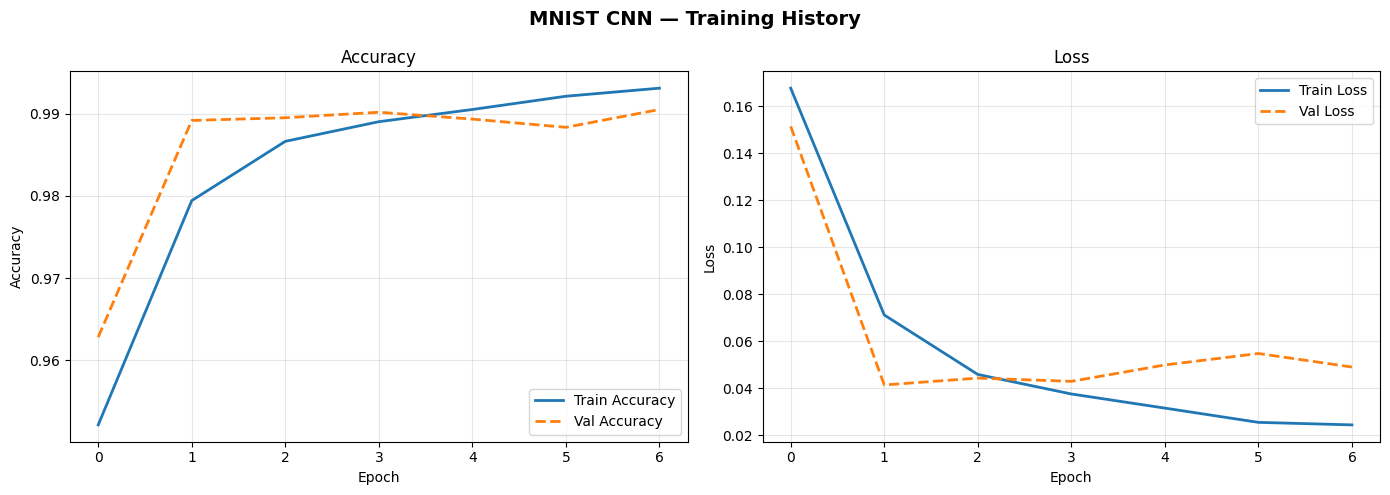

Saved → training_history.png


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MNIST CNN — Training History', fontsize=14, fontweight='bold')

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2, linestyle='--')
ax1.set_title('Accuracy');  ax1.set_xlabel('Epoch');  ax1.set_ylabel('Accuracy')
ax1.legend();  ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'],     label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
ax2.set_title('Loss');  ax2.set_xlabel('Epoch');  ax2.set_ylabel('Loss')
ax2.legend();  ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=120)
plt.show()
print('Saved → training_history.png')

##  Step 8 — Confusion Matrix

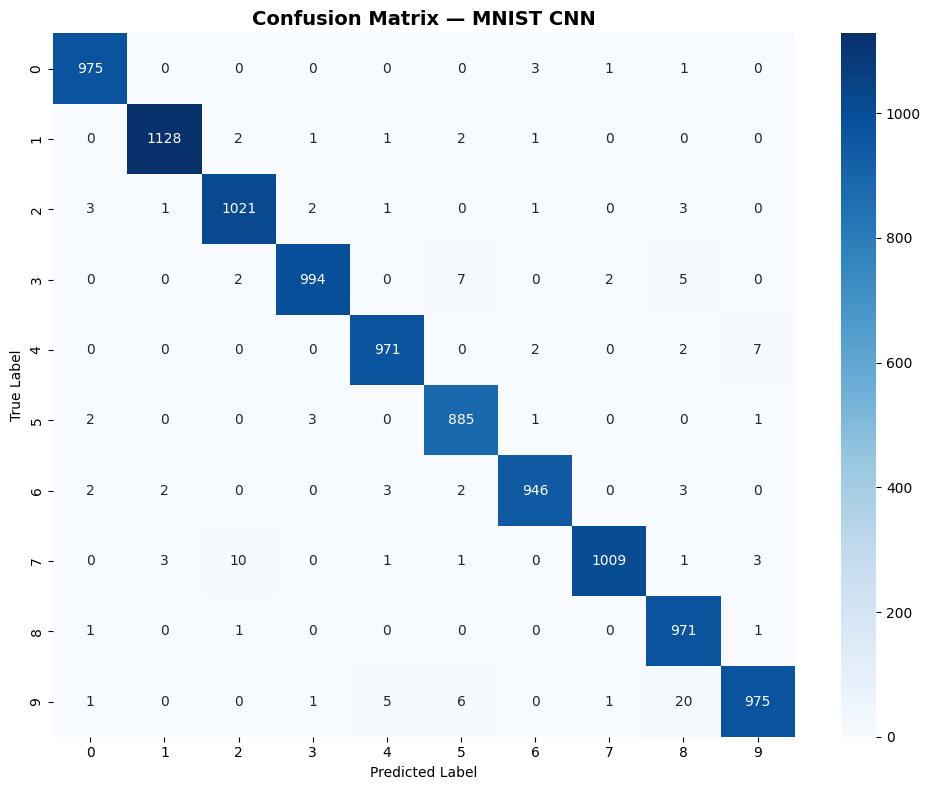

Saved → confusion_matrix.png


In [9]:
cm = confusion_matrix(y_test_raw, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix — MNIST CNN', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()
print('Saved → confusion_matrix.png')

## Step 9 — Sample Predictions

Visualise 10 random predictions. **Green** = correct, **Red** = wrong.

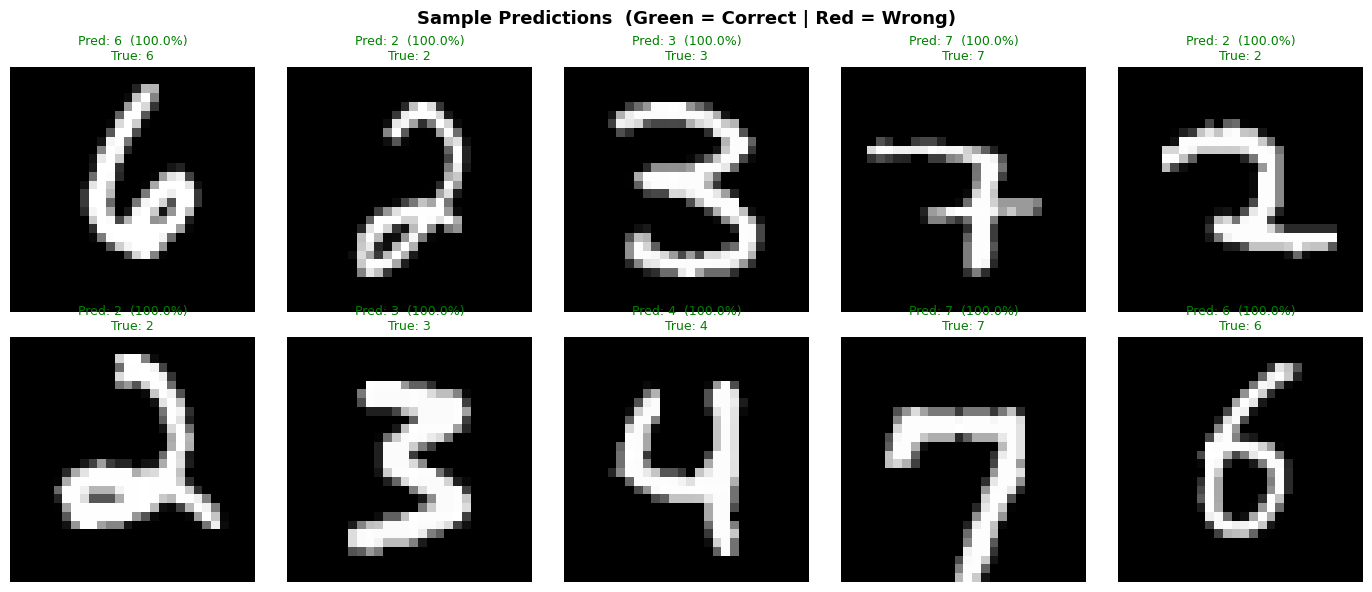

Saved → predictions.png


In [10]:
indices = np.random.choice(len(X_test), 10, replace=False)
probs   = model.predict(X_test[indices], verbose=0)
preds   = np.argmax(probs, axis=1)
confs   = np.max(probs, axis=1) * 100

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample Predictions  (Green = Correct | Red = Wrong)',
             fontsize=13, fontweight='bold')

for i, (idx, ax) in enumerate(zip(indices, axes.flat)):
    ax.imshow(X_test[idx].squeeze(), cmap='gray')
    color = 'green' if preds[i] == y_test_raw[idx] else 'red'
    ax.set_title(f'Pred: {preds[i]}  ({confs[i]:.1f}%)\nTrue: {y_test_raw[idx]}',
                 color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('predictions.png', dpi=120)
plt.show()
print('Saved → predictions.png')

##  Step 10 — Save the Final Model

In [11]:
model.save('mnist_cnn_final.keras')
print(' Model saved → mnist_cnn_final.keras')
print()
print('Output files generated:')
print('  • sample_digits.png      – sample training images')
print('  • training_history.png   – accuracy & loss curves')
print('  • confusion_matrix.png   – per-class performance')
print('  • predictions.png        – random test predictions')
print('  • best_mnist_model.keras – best checkpoint')
print('  • mnist_cnn_final.keras  – final saved model')

 Model saved → mnist_cnn_final.keras

Output files generated:
  • sample_digits.png      – sample training images
  • training_history.png   – accuracy & loss curves
  • confusion_matrix.png   – per-class performance
  • predictions.png        – random test predictions
  • best_mnist_model.keras – best checkpoint
  • mnist_cnn_final.keras  – final saved model
